In [ ]:
%conda install matplotlib

In [ ]:
%conda update -n base -c defaults conda
%conda install seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정 (windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 데이터 로드 : 자동차 연비 데이터
mpg = sns.load_dataset('mpg')
print( mpg.info() )
print( mpg.head() )


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17

2. 첫 번째 객체 지향 차트: 선 그래프

model_year
70    17.689655
71    21.250000
72    18.714286
73    17.100000
74    22.703704
75    20.266667
76    21.573529
77    23.375000
78    24.061111
79    25.093103
80    33.696552
81    30.334483
82    31.709677
Name: mpg, dtype: float64


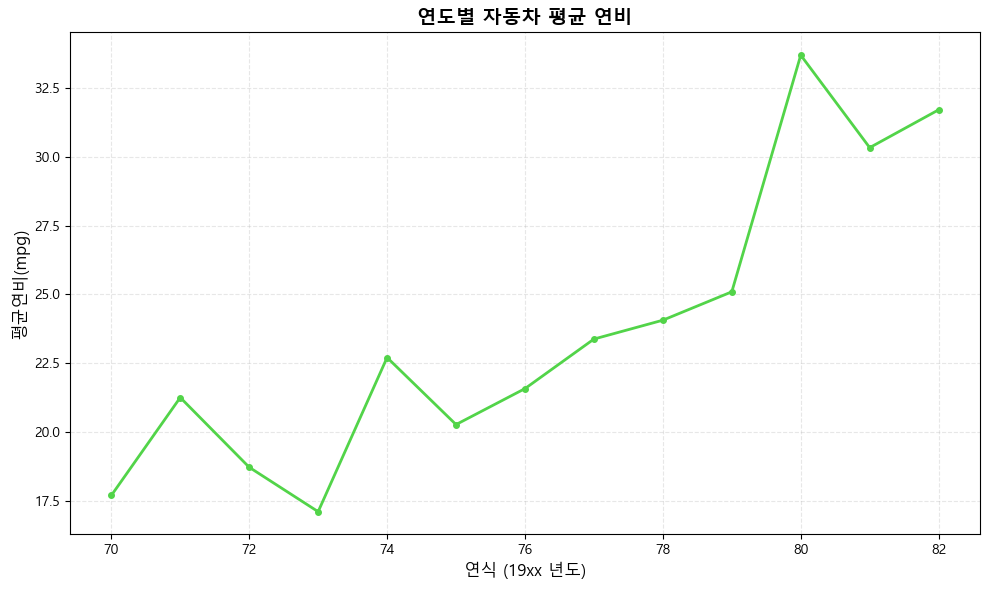

In [5]:
# 연도별 평균 연비 계산
yearly_mpg = mpg.groupby('model_year')['mpg'].mean()
print(yearly_mpg)
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(yearly_mpg.index, yearly_mpg.values,
        marker = 'o', linewidth=2, markersize = 4, color='#52d449')
ax.set_xlabel('연식 (19xx 년도)', fontsize=12)
ax.set_ylabel('평균연비(mpg)', fontsize=12)
ax.set_title('연도별 자동차 평균 연비', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [14]:
mpg['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

3. 막대 차트: 범주형 비교

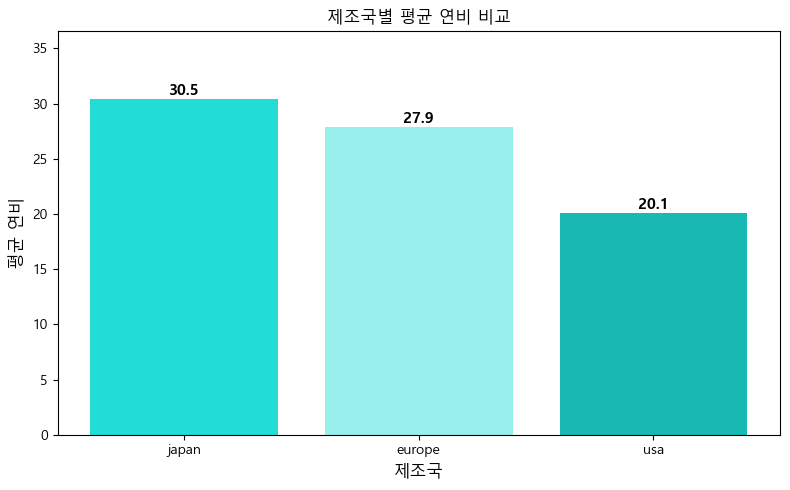

In [50]:
# 제조국별 (origin)별 평균 연비
origin_mpg = mpg.groupby('origin')['mpg'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(origin_mpg.index, origin_mpg.values, color=['#22dcd6','#98f0ed','#18b9b3'],
       #edgecolor = 'black',
        linewidth=0) # 테두리 두께

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('제조국', fontsize=12)
ax.set_ylabel('평균 연비', fontsize=12)
ax.set_title('제조국별 평균 연비 비교')
ax.set_ylim(0, origin_mpg.max()*1.2)
plt.tight_layout()
plt.show()

4. 산점도 : 두 변수의 관계

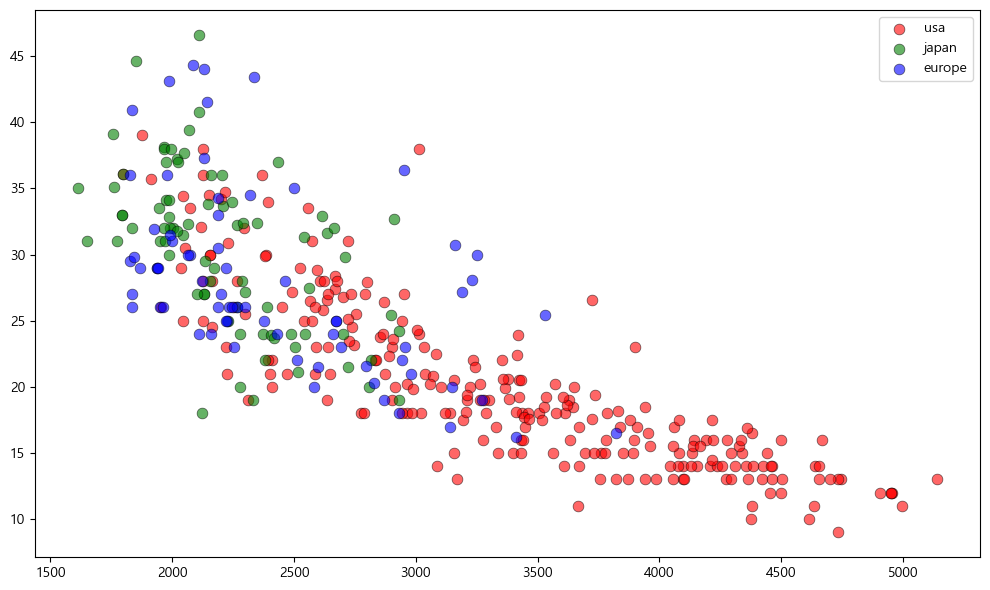

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'usa' : 'r', 'japan' : 'g', 'europe' : 'b'}
for origin, color in colors.items():
    mask = mpg['origin'] == origin
    ax.scatter(mpg[mask]['weight'], mpg[mask]['mpg'], c = color, label=origin,
              alpha=0.6, s=60, edgecolors='black', linewidths=0.5)
ax.legend()
plt.tight_layout()
plt.show()

5. 스타일 커스터마이징

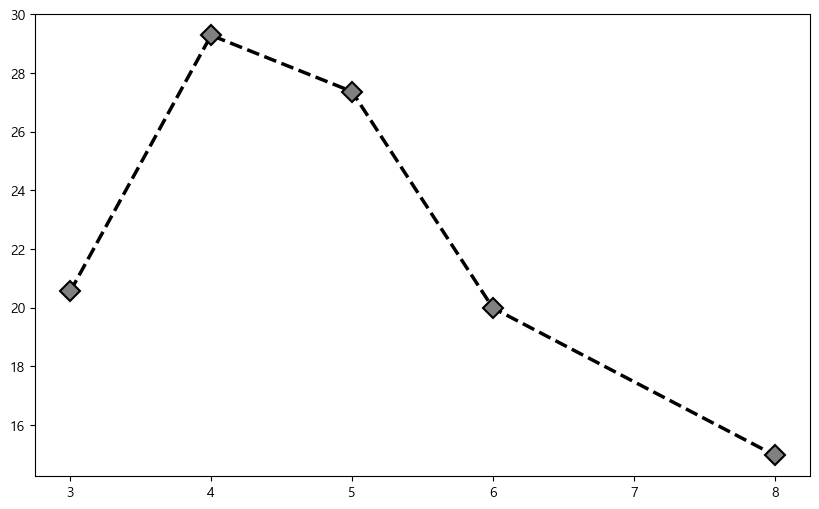

In [68]:
cylinder_groups = mpg.groupby('cylinders')['mpg'].mean()
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(cylinder_groups.index, cylinder_groups.values,
        marker='D', linestyle='--', linewidth=2.5, markersize=10,
        color='k', markerfacecolor='gray', markeredgecolor='black', markeredgewidth = 1.5)
plt.show()